# Data Visualization Using `plotnine` and the grammar of graphics



## Cars Data

The Palmer Penguins dataset had a variety of column types with which to explore some nice visualizations. The `mtcars` dataset is another popular dataset for doing some simple data work, but does not contain the same types of variables.

Run the following code to load the `mtcars` dataset and explore the observations and variables contained within. To learn more about this dataset check out [this site](https://stat.ethz.ch/R-manual/R-devel/library/datasets/html/mtcars.html)

In [65]:
import statsmodels.api as sm
import pandas as pd

mtcars = sm.datasets.get_rdataset("mtcars", "datasets", cache=True).data
df = pd.DataFrame(mtcars)

In [66]:
df

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
rownames,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2


The statement "the `mtcars` dataset does not contain the same types of variables as the penguins dataset" is a little true and a little false. There are no variables that contain text values, BUT there are variables that it makes sense to consider categorical variables. In most situations, it makes sense to treat the values of categorical variables as text values instead of numeric values.

Some of these variables, like the `cyl` variable, have numeric values that actually make sense as numbers (i.e. the number of cylinders in the engine). However, it doesn't make the most sense to "do math" with this type of variable (e.g. take averages and such) because there are so few different value this can take on AND they're an explicit choice made by the car manufacturer. So, it makes more sense to treat the `cyl` variable as a categorical variable despite it having numeric values.

You will need to keep these kinds of nuances about data in mind as you work with an increasing variety and richness of data, and do more complex things with them

Use the `astype()` method to convert the categorical variables of the `mtcars` (df) dataset to have text values in the code chunk below. We've done one for you!

In [67]:
df.dtypes

mpg     float64
cyl       int64
disp    float64
hp        int64
drat    float64
wt      float64
qsec    float64
vs        int64
am        int64
gear      int64
carb      int64
dtype: object

In [68]:
df["am"] = df["am"].astype(str)

# Convert the other variables below

In [69]:
df["cyl"] = df["cyl"].astype(str)

In [70]:
df["vs"] = df["vs"].astype(str)

In [71]:
df

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
rownames,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2


In [72]:
df.dtypes

mpg     float64
cyl      object
disp    float64
hp        int64
drat    float64
wt      float64
qsec    float64
vs       object
am       object
gear      int64
carb      int64
dtype: object

If you print out your new dataset, is it clear that the variables have been converted to text values? If so, how can you tell?

Let's see how `plotnine` treats these variables.


ANS: When I print out the new dataset itself it is not obvious that the variables have been converted to text values. However, when I check the type before and after converting the variables, the change from int64 to object is there.

1\. Create side-by-side boxplots of the `mpg` variable by the different values of the `am` variable.

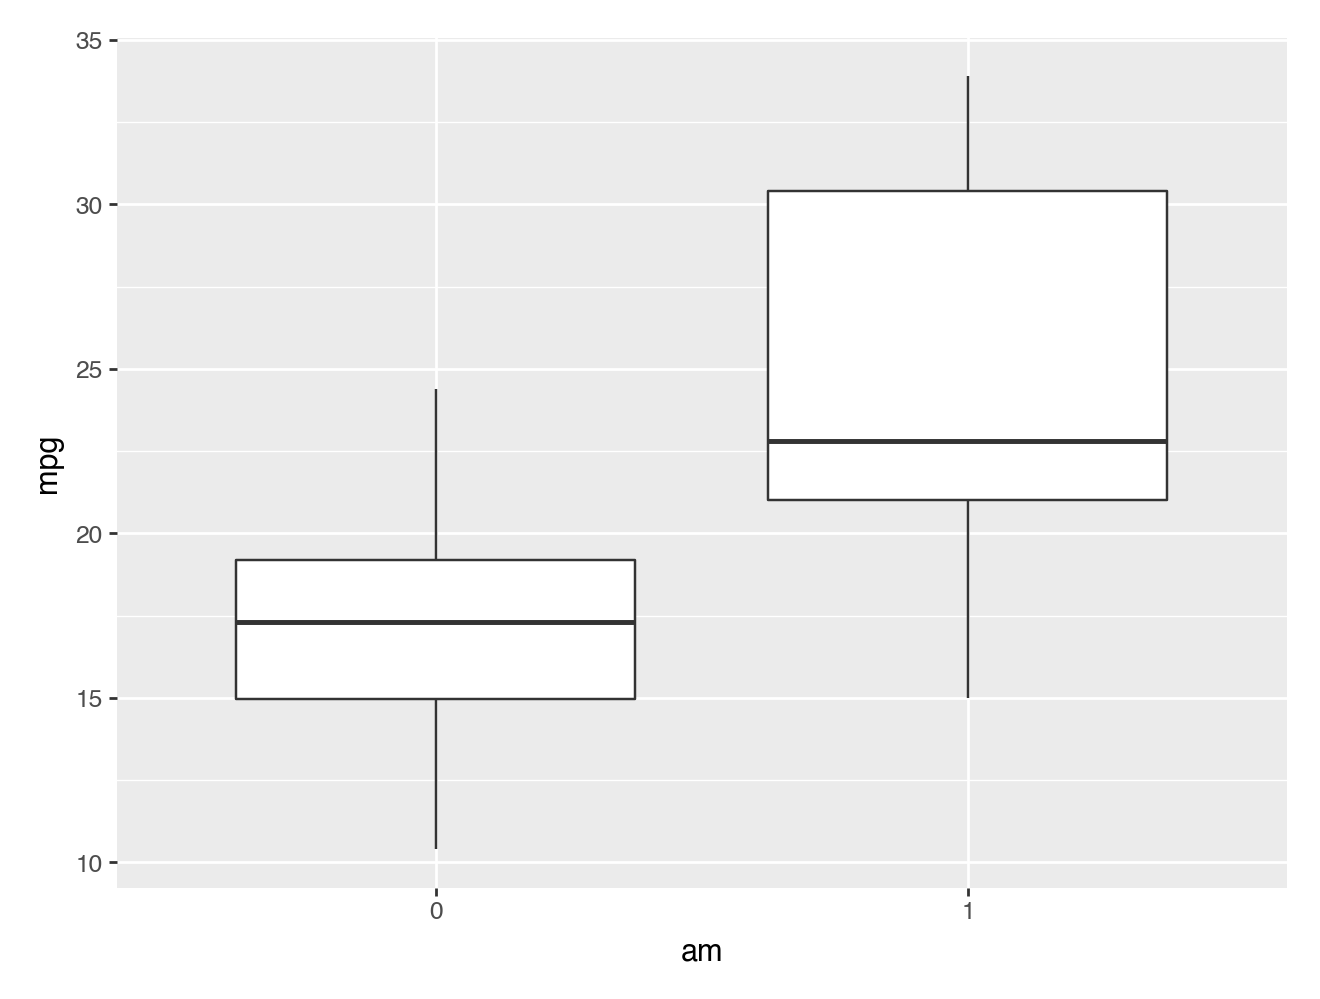

In [73]:
# Enter your code here
from plotnine import ggplot, geom_point, aes, geom_boxplot

(ggplot(df,
aes(
  x = "am",
  y = "mpg",
))
+ geom_boxplot()
)

2\. What happens if you convert the `am` variable back to float values and then try to create the same plot as in the previous part? Explain the differences between the two plots.

In [74]:
df.dtypes

mpg     float64
cyl      object
disp    float64
hp        int64
drat    float64
wt      float64
qsec    float64
vs       object
am       object
gear      int64
carb      int64
dtype: object

In [75]:
# convert am variable back to float
df["am"] = df["am"].astype(float)

In [76]:
df.dtypes

mpg     float64
cyl      object
disp    float64
hp        int64
drat    float64
wt      float64
qsec    float64
vs       object
am      float64
gear      int64
carb      int64
dtype: object

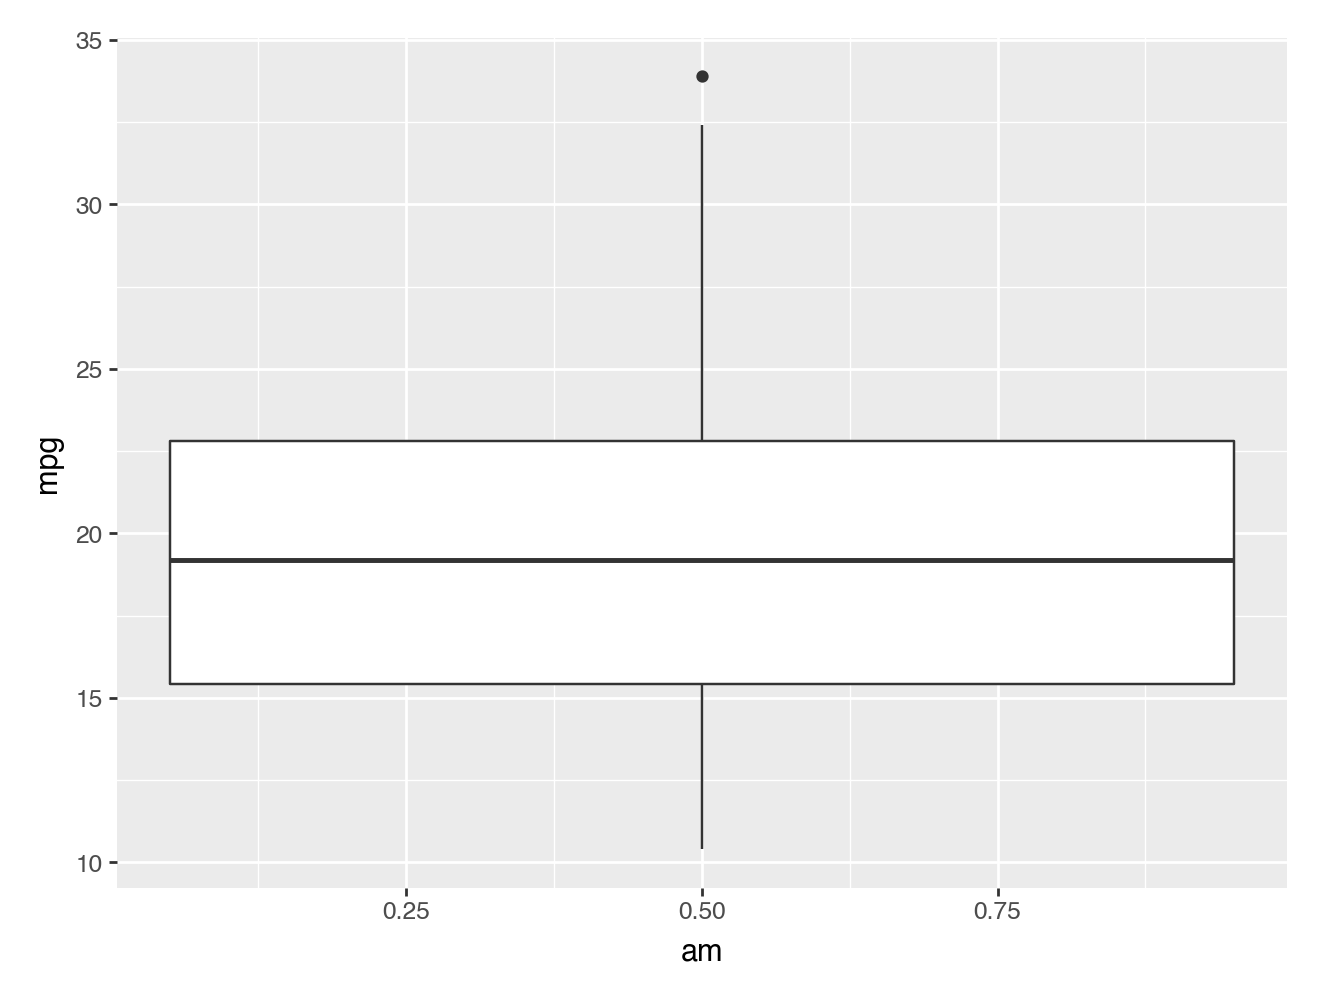

In [77]:
# boxplot
from plotnine import ggplot, geom_point, aes, geom_boxplot

(ggplot(df,
aes(
  x = "am",
  y = "mpg",
))
+ geom_boxplot()
)

3\. Create overlaid histograms of the `hp` variable for the different values of the `cyl` variable.

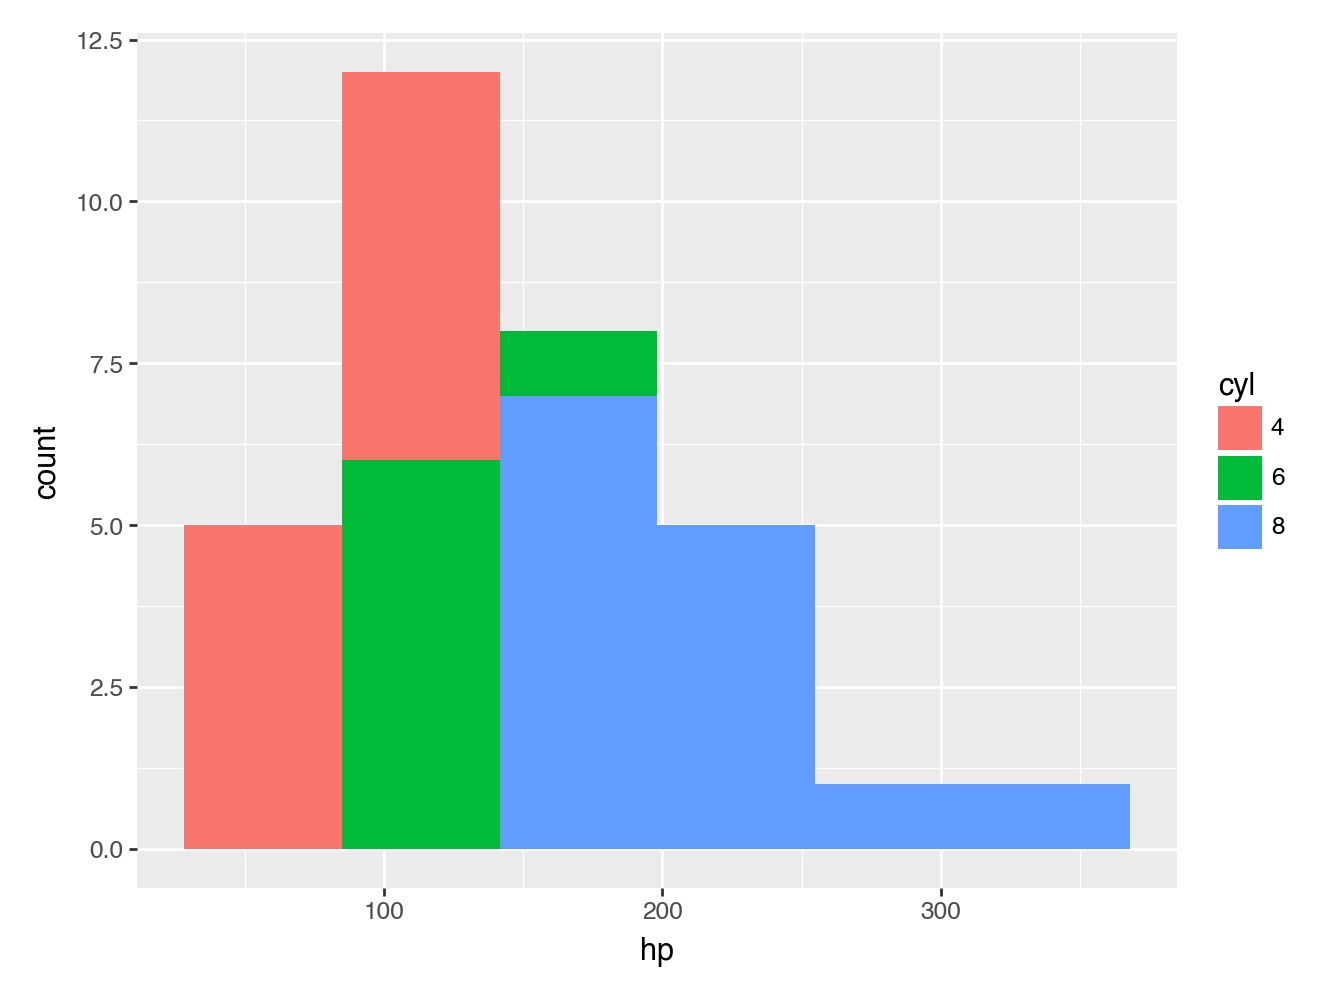

In [78]:
from plotnine import geom_histogram
(ggplot(df,
aes(
  x = "hp",
  fill = "cyl"
))
+ geom_histogram()
)

4\. What happens if you convert the `cyl` variable back to float values and then try to create the same plot as in the previous part? Explain the differences between the two plots.

In [79]:
df.dtypes

mpg     float64
cyl      object
disp    float64
hp        int64
drat    float64
wt      float64
qsec    float64
vs       object
am      float64
gear      int64
carb      int64
dtype: object

In [80]:
# convert cyl variable back to float
df["cyl"] = df["cyl"].astype(float)

In [81]:
df.dtypes

mpg     float64
cyl     float64
disp    float64
hp        int64
drat    float64
wt      float64
qsec    float64
vs       object
am      float64
gear      int64
carb      int64
dtype: object

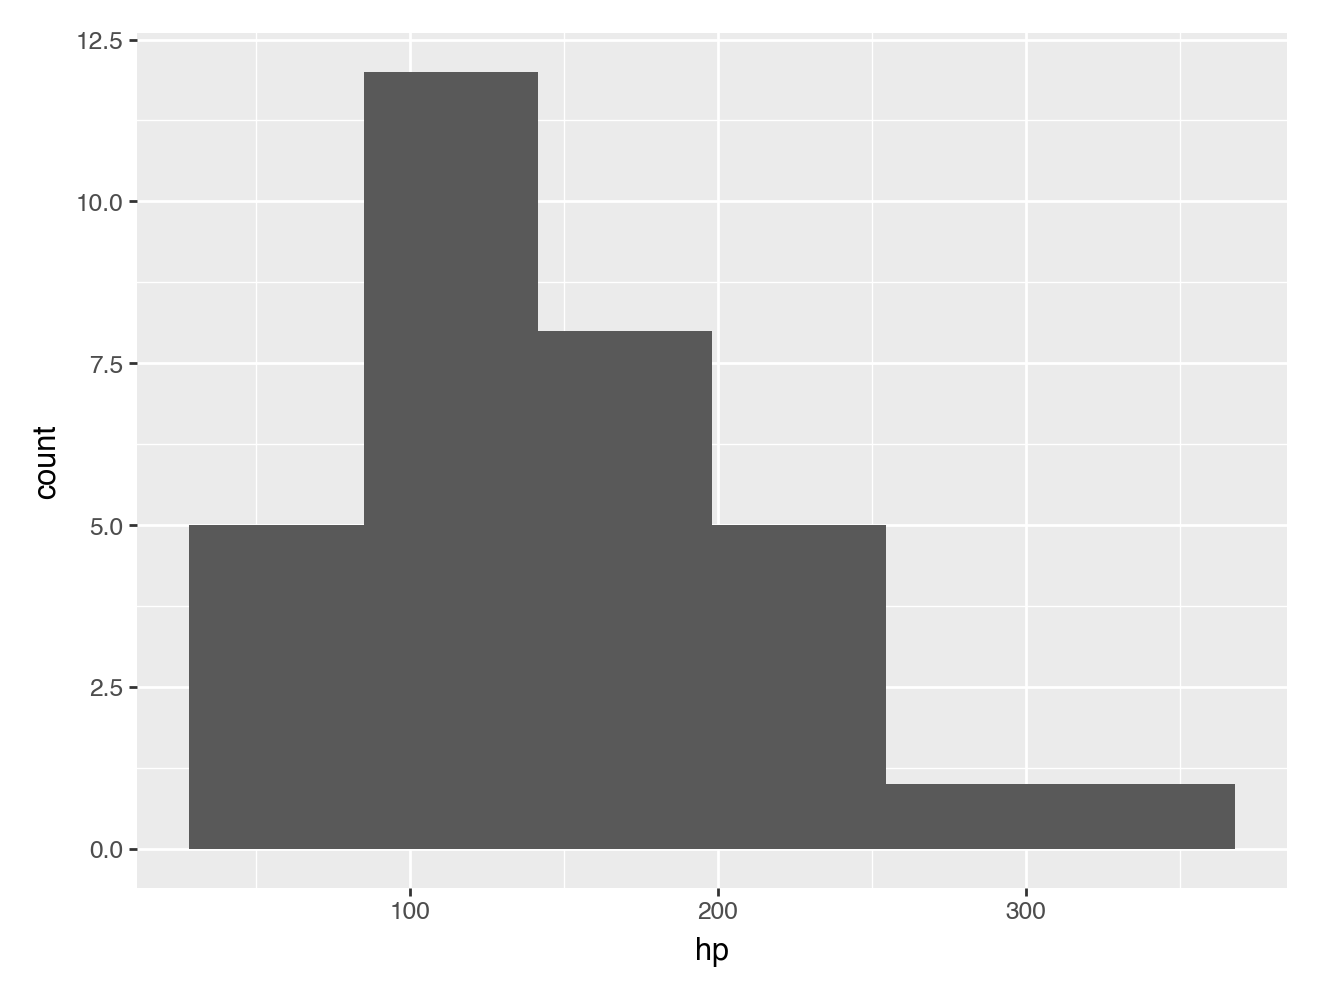

In [82]:
# replot
from plotnine import geom_histogram
(ggplot(df,
aes(
  x = "hp",
  fill = "cyl"
))
+ geom_histogram()
)

ANS: The previous plot with cyl being categorical had those colorful sections for those categories.
Since the plot is now based on cyl that is numerical and not categorical. The fill is all greyscale as there are no categories to differeniate and such.

5\. Choose a new `geometry` from the [data-to-viz website](https://www.data-to-viz.com/) or look in the [`plotnine` graph gallery](https://python-graph-gallery.com/plotnine/) for a graph that you'd like to explore using the `mtcars` dataset, and then create that graph. Share your graph with a classmate and discuss it's advantages and disadvantages.

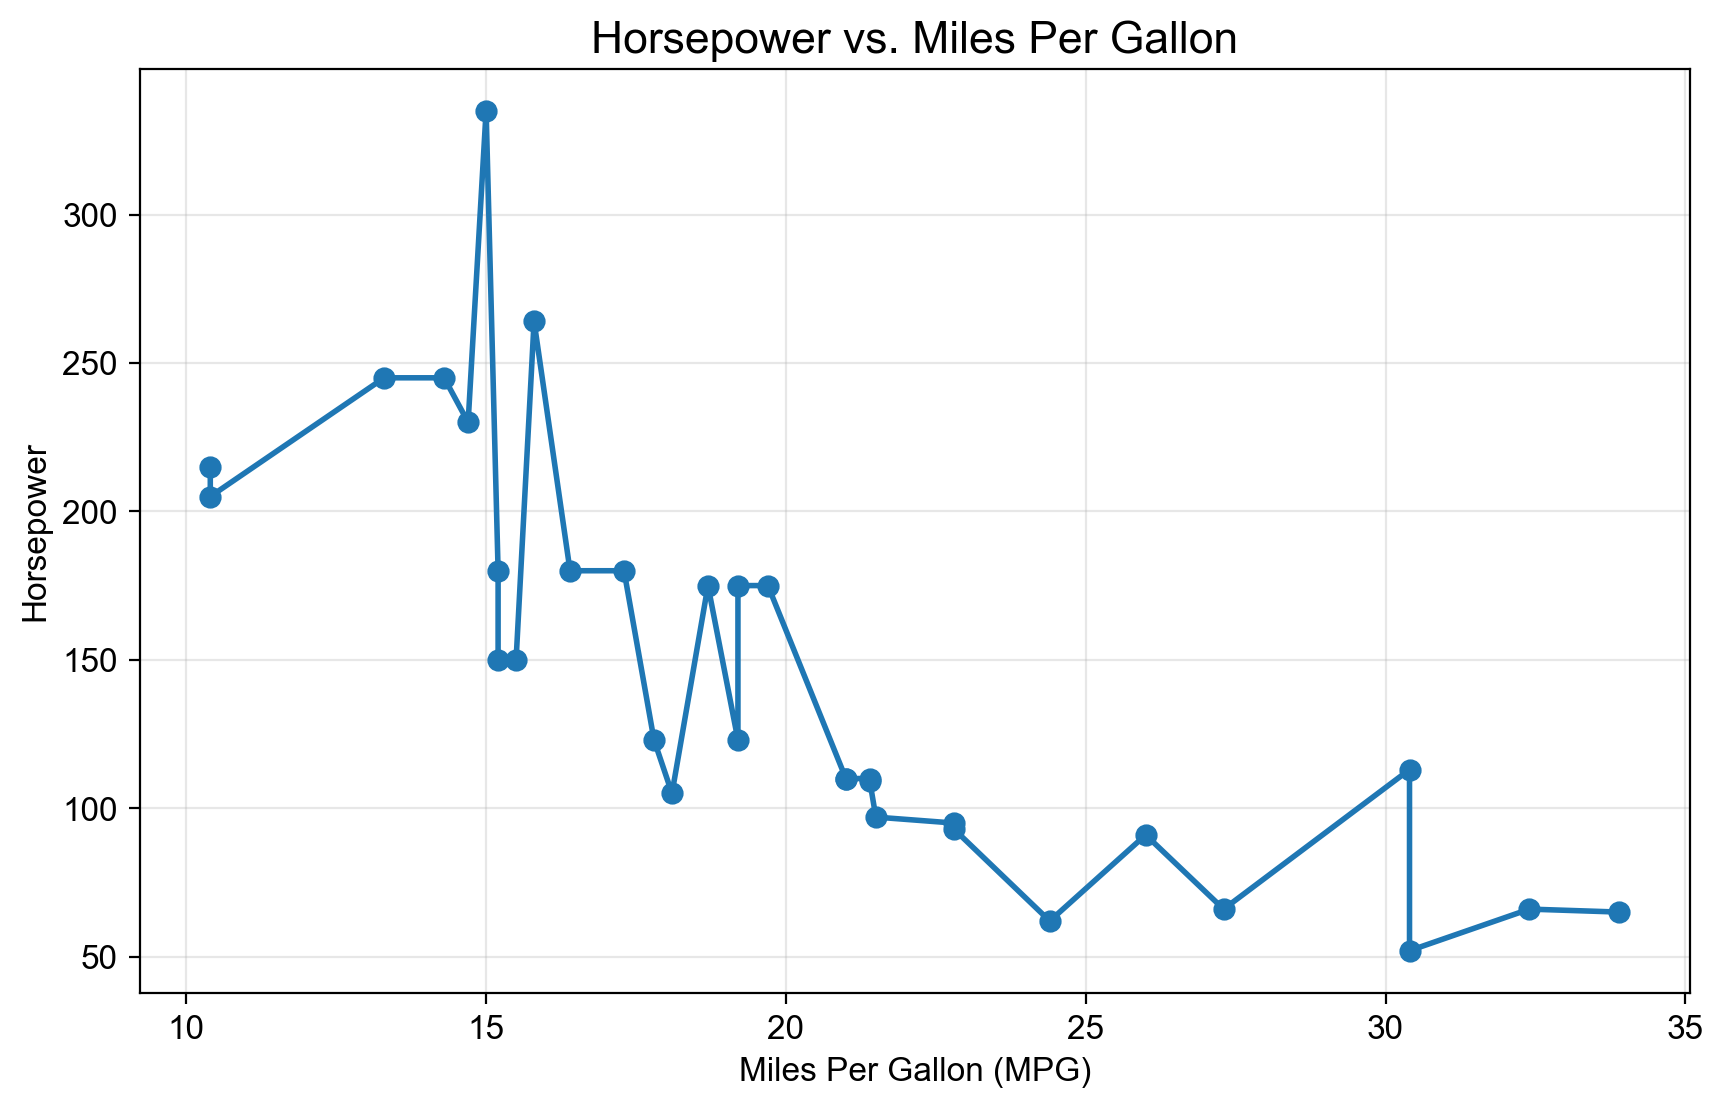

In [83]:
import matplotlib.pyplot as plt

df_sorted = df.sort_values('mpg')

plt.figure(figsize=(10, 6))

plt.plot(
    'mpg',
    'hp',
    data=df_sorted,
    linestyle='-',
    marker='o',
    linewidth=2,
    markersize=7
)

plt.title('Horsepower vs. Miles Per Gallon', fontsize=16)
plt.xlabel('Miles Per Gallon (MPG)', fontsize=12)
plt.ylabel('Horsepower', fontsize=12)

plt.grid(alpha=0.3)

plt.show()

Discussed Advantages: The simple lines and connecting dots show the relationship pattern well. Also the lines make it easy to follow what's negative/positive.
Discussed Disadvantages: Every dot is supposed to represent a car, but that is not necessarily that obvious from the chart. It can be very cluttered if there's a bigger dataset. Also, if something was repeated it is not that clean of a look.

6\. Repeat the previous part for another graph that you'd like to explore using the `mtcars` dataset, and then create that graph. Share your graph with a classmate and discuss it's advantages and disadvantages.

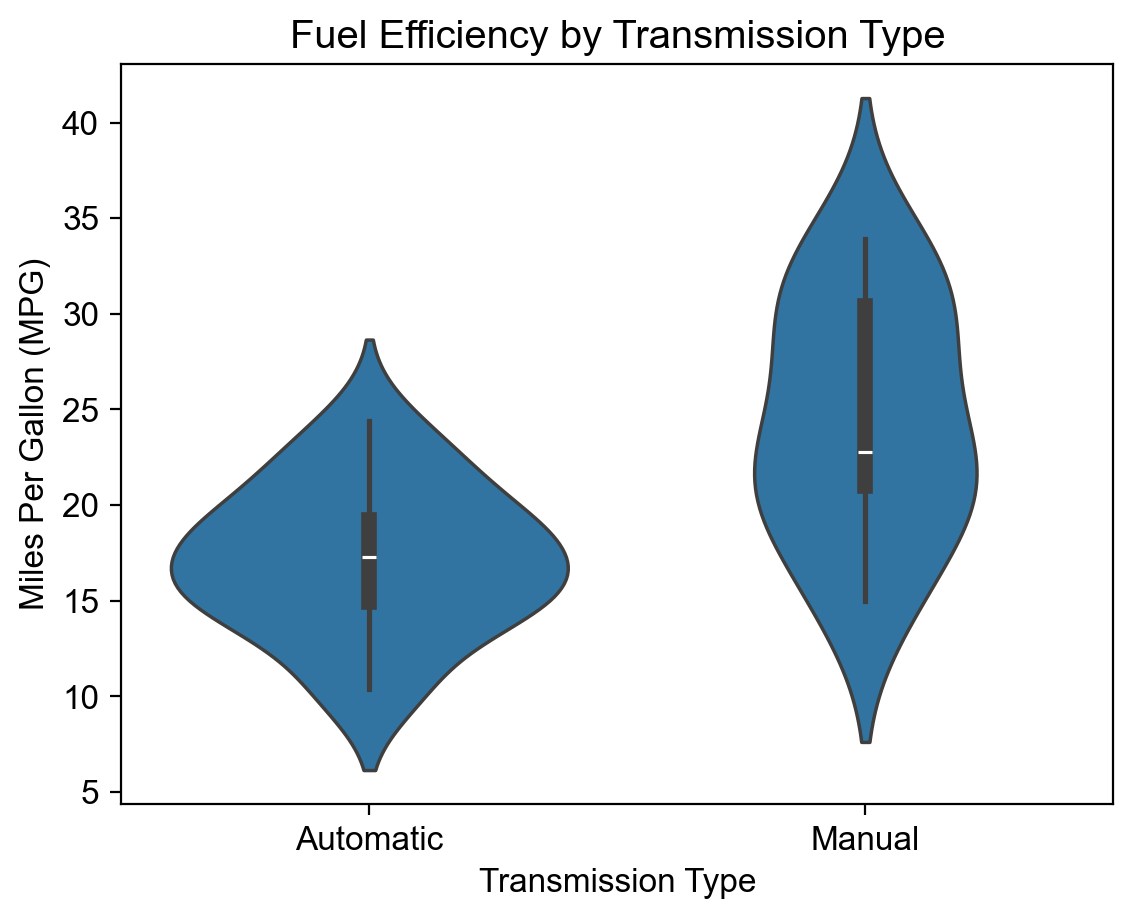

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.violinplot(x=df["am"], y=df["mpg"])

plt.title("Fuel Efficiency by Transmission Type")
plt.xlabel("Transmission Type")
plt.ylabel("Miles Per Gallon (MPG)")
plt.xticks([0, 1], ["Automatic", "Manual"])

plt.show()

Discussed Advantages: Makes it very easy to compare automatic vs manual cars. Shows each individual miles per gallon estimate pretty clearly if you just follow y-axis.
Discussed Disadvantages: Width of the violins are not defined and can be hard for a new viewer to know that it's density. The wider it is it's supposed to be more cars that have that many mpg.

## FEV Data

(You saw this data set in [GSB 518](https://kevin-davisross.quarto.pub/gsb518-notes/hw-09.html#problem-3).) Do non-smokers have better lungs than smokers? One measure of lung function is forced expiratory volume (FEV), the amount of air (in liters) an individual can exhale in the first second of forceful breath. Larger values of FEV are indicative of better functioning lungs. In a study, FEV was measured for a group of 654 subjects, along with whether they smoked and other variables like age (years). [Here is the data.](https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/FEV.csv)

[This plot](https://drive.google.com/file/d/1dm7U1cpVpHrbNZrBymOdmtkhMX3U7BwU/view?usp=sharing) was made using `plotly`. Use AI to help reproduce it using `plotnine`. Think in terms of the grammar of graphics and the design of the plot and write prompts like "The x-axis is mapped to Age". It might help to [try the two practice activities in Section 3.6.3 first](https://ds-ml-with-python.github.io/Course-Textbook/02-plotnine.html#try-it-out). (Hint: this is really 3 separate plots. Consider using the `patchworklib` package, which you need to install in Colab space first.)


In [85]:
df_fev = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/FEV.csv")
df_fev

,ID,Smoking status,FEV,Height,Age (months)
0,201,non-smoker,2.884,69.0,132
1,202,non-smoker,2.328,64.0,120
2,301,non-smoker,1.708,57.0,108
3,341,non-smoker,3.381,63.0,172
4,351,non-smoker,2.170,58.0,130
...,...,...,...,...,...
649,83841,non-smoker,2.115,50.0,58
650,83901,non-smoker,2.328,60.0,98
651,83951,smoker,3.069,65.0,130
652,83952,non-smoker,1.495,57.0,85


In [86]:
# provided FEV code
import plotly.express as px

px.scatter(df_fev, x="Age (months)", y="FEV", color="Smoking status",
           marginal_x="histogram", marginal_y="histogram", trendline="ols", template="simple_white")


In [87]:
!pip install patchworklib

In [88]:
import patchworklib as pw

In [89]:
from plotnine import ggplot, aes, geom_point, geom_smooth

p1= (ggplot(df_fev, aes(x="Age (months)", y="FEV", color="Smoking status"))
 + geom_point()
 + geom_smooth(method='lm', se=False))


In [90]:
from plotnine import ggplot, aes, geom_histogram

p2 = (ggplot(df_fev, aes(x='Age (months)', fill='Smoking status'))
 + geom_histogram())


In [91]:
from plotnine import ggplot, aes, geom_histogram, coord_flip

p3 = (ggplot(df_fev, aes(x='FEV', fill='Smoking status'))
 + geom_histogram()
 + coord_flip())


## Olympic Men's Gymnastics Data

[This file](https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv) contains scores from the qualification and final rounds of the Olympic men's gymnastics all around competition from 2008 to 2020. (Thanks to Martin Hsu for scraping this data set.)

1\. Your goal will be to create a graphic which summarizes the distribution of scores across events and years, and any other features you want to add. But first...


This data is in "wide format" in that the scores are spread over six columns.

| Floor score | Pommel score | Rings score | Vault score | Pbar score | Hbar score |
|------------:|-------------:|------------:|------------:|-----------:|-----------:|
|        15.0 |         14.5 |        15.2 |        16.1 |       14.6 |       15.0 |


In order to produce some plots (and work with the grammar of graphics more fully), you might need to reformat the data so that it is "long format" with one column for score and a new column for "event".

| Event  | Score |
|--------|------:|
| Floor  |  15.0 |
| Pommel |  14.5 |
| Rings  |  15.2 |
| Vault  |  16.1 |
| Pbar   |  14.6 |
| Hbar   |  15.0 |

Create a new data frame with the scores in long format, with columns labeled "Event" and "Score". There are a few ways to do this, so see what you can find!


In [92]:
df_gym = pd.read_csv("https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv")
df_gym

,Pos,Gymnast,NOC,Points,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse,Round,Year
0,1.0,Danell Leyva,USA,91.265,15.100,15.500,15.333,15.866,14.600,14.866,Qualification,2012
1,2.0,David Belyavsky,RUS,90.832,15.100,16.300,15.300,14.866,14.366,14.900,Qualification,2012
2,3.0,Fabian HambÃ¼chen,GER,90.765,15.133,15.833,15.300,15.633,14.766,14.100,Qualification,2012
3,4.0,John Orozco,USA,90.597,15.166,15.800,14.533,15.266,15.066,14.766,Qualification,2012
4,5.0,Kristian Thomas,GBR,90.256,15.366,16.200,14.625,15.366,14.566,14.133,Qualification,2012
...,...,...,...,...,...,...,...,...,...,...,...,...
346,20.0,Daniel Keatings,GBR,89.000,14.850,15.800,14.425,14.225,14.000,15.700,Final,2008
347,21.0,Thomas Bouhail,FRA,87.000,15.200,15.850,14.425,14.475,13.650,13.400,Final,2008
348,22.0,José Luis Fuentes,VEN,86.300,14.175,15.250,15.175,14.150,13.900,13.650,Final,2008
349,23.0,Dzmitry Savitski,BLR,82.175,13.725,15.900,13.400,10.100,15.300,13.750,Final,2008


In [93]:
# Code for reshaping gymnastics data into long format:
df_gym_long = df_gym.melt(id_vars = ["Gymnast", "NOC", "Round", "Year"],
                          value_vars=["Floor Exercise", "Pommelled Horse", "Rings", "Horse Vault", "Parallel Bars", "Horizontal Bar"],
                          var_name = "event", value_name = "score")

In [94]:
df_gym_long

,Gymnast,NOC,Round,Year,event,score
0,Danell Leyva,USA,Qualification,2012,Floor Exercise,15.100
1,David Belyavsky,RUS,Qualification,2012,Floor Exercise,15.100
2,Fabian HambÃ¼chen,GER,Qualification,2012,Floor Exercise,15.133
3,John Orozco,USA,Qualification,2012,Floor Exercise,15.166
4,Kristian Thomas,GBR,Qualification,2012,Floor Exercise,15.366
...,...,...,...,...,...,...
2101,Daniel Keatings,GBR,Final,2008,Horizontal Bar,14.225
2102,Thomas Bouhail,FRA,Final,2008,Horizontal Bar,14.475
2103,José Luis Fuentes,VEN,Final,2008,Horizontal Bar,14.150
2104,Dzmitry Savitski,BLR,Final,2008,Horizontal Bar,10.100


2\. Now create a graphic which summarizes the distribution of scores across events and years, and any other features you want to add. Be creative! Share your graph with a classmate and discuss why you designed it the way you did.

In [95]:
from plotnine import *

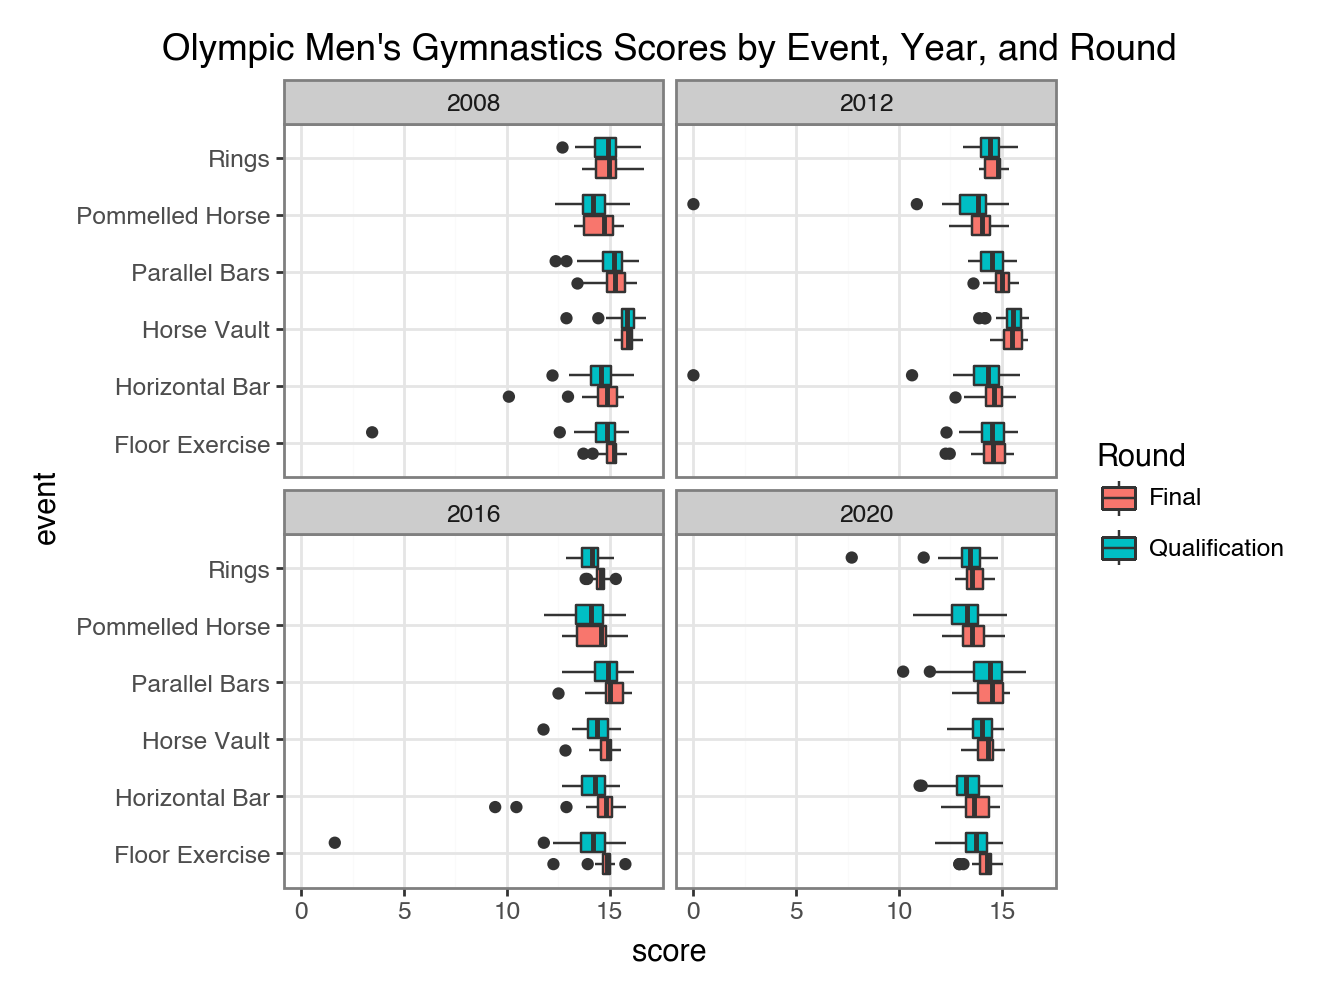

In [96]:
(
    ggplot(df_gym_long.dropna(),
           aes(x="event", y="score", fill="Round"))
    + geom_boxplot()
    + facet_wrap("Year")
    + coord_flip()
    + labs(
        x="event",
        y="score",
        fill="Round",
        title="Olympic Men's Gymnastics Scores by Event, Year, and Round"
    )
    + theme_bw()
)

^ Used chatGPT to be able to fit all of the event names. taught me coord_flip!

I used boxplots bc they are easy to compare multiple events and each of their numerical values. Separating by year made the most sense because it is how we typically compartmentalize the different levels of performance each time people complete the Olympics, we refer by year! I decided to add Round to compare and see if some performances were better in the qualifiying than the finals. Even though we can't really come to a strong conclusion as to why specific performances in the qualifiying may have been better than the finals and vice versa.